In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [2]:
sessions = pd.read_csv("C:/Users/thinh/Desktop/Python Data/sessions.csv")

## Conversion Modeling

### Logistic Regression Model

A logistic regression model is used to estimate the probability that a session results in a purchase based on observed behavioral features.

In [3]:
model3 = smf.logit("converted ~ log_views + log_duration + has_cart + avg_view_price + is_weekend + num_unique_brand + hour_sin + hour_cos", data = sessions).fit()
print(model3.summary())

Optimization terminated successfully.
         Current function value: 0.097778
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:               222013
Model:                          Logit   Df Residuals:                   222004
Method:                           MLE   Df Model:                            8
Date:                Sun, 08 Mar 2026   Pseudo R-squ.:                  0.2754
Time:                        23:47:59   Log-Likelihood:                -21708.
converged:                       True   LL-Null:                       -29958.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -5.5608      0.043   -130.446      0.000      -5.644      -5.477
has_cart[T.

## Baseline Model

In [4]:
# -------------------------------------------------------------------------
# Model 1: Baseline Conversion Model
# -------------------------------------------------------------------------
# Uses basic engagement signals to estimate purchase probability


X = sessions[["num_views", "session_duration","has_cart","avg_view_price"]]

y = sessions["converted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.3,
    random_state = 42,
    stratify = y #because conversion rate is low at 3%
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

y_pred_prob = model.predict_proba(X_test)[:,1]

test_auc = roc_auc_score(y_test,y_pred_prob)
test_auc

0.7897101891947254

### No Cart Feature Model

In [5]:
# --------------------------------------------------------------
# No Cart Feature
# --------------------------------------------------------------

X2 = sessions[["num_views","session_duration","avg_view_price"]]

y = sessions["converted"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y,
    test_size = 0.3,
    random_state = 42,
    stratify = y
)

model2 = LogisticRegression(max_iter = 1000)
model2.fit(X2_train,y2_train)

y_pred_prob2 = model2.predict_proba(X2_test)[:,1]
test_auc_2 = roc_auc_score(y_test,y_pred_prob2)
test_auc_2

0.7181865841659656

## Feature Engineering Model

In [6]:
# ----------------------------------------------------------------------------------------------------------------------------------
# Model 3: Feature Engineering Model
# ----------------------------------------------------------------------------------------------------------------------------------
# Adds behavioral and temporal features to improve predictive power

X3 = sessions[["log_views" , "log_duration", "has_cart", "avg_view_price","is_weekend", "num_unique_brand", "hour_sin", "hour_cos"]]

y = sessions["converted"]

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y,
    test_size = 0.3,
    random_state = 42,
    stratify = y
)

model3 = LogisticRegression(max_iter = 1000)
model3.fit(X3_train, y3_train)

y_pred_prob3 = model3.predict_proba(X3_test)[:,1]
test_auc_3 = roc_auc_score(y_test,y_pred_prob3)
test_auc_3

0.9050999695329592

In [7]:
# Check correlation among predictors to identify potential multicollinearity concerns.
feature_corr = sessions[
    ["has_cart","num_views","session_duration", "avg_view_price"]
].corr()

feature_corr
# Correlation analysis showed low pairwise relationship among predictors (all |r| < 0.25), indicating minimal multicollinearity concerns.

,has_cart,num_views,session_duration,avg_view_price
has_cart,1.000000,0.132317,0.044024,-0.160007
num_views,0.132317,1.000000,0.217704,-0.010302
session_duration,0.044024,0.217704,1.000000,0.002572
avg_view_price,-0.160007,-0.010302,0.002572,1.000000


In [8]:
model_comparison = pd.DataFrame({
    "Model": ["Baseline", "No Cart Feature", "Feature Engineered"],
    "AUC": [test_auc, test_auc_2, test_auc_3]
})

model_comparison

,Model,AUC
0,Baseline,0.789710
1,No Cart Feature,0.718187
2,Feature Engineered,0.905100


## Model Evaluation

In [9]:
# --------------------------------------------------------------------
# Single feature predictive power
# --------------------------------------------------------------------
# Evaluate how well individual behavioral signals predict conversion.

feature_auc = {
   "avg_view_price": roc_auc_score(y, sessions["avg_view_price"]),
   "num_unique_brand": roc_auc_score(y, sessions["num_unique_brand"]),
   "log_duration": roc_auc_score(y, sessions["log_duration"]),
   "log_views": roc_auc_score(y, sessions["log_views"])
}

feature_auc

# Session duration and number of brands explored showed the strongest individual
# predictive signal, suggesting deeper browsing behavior is strongly associated
# with purchase intent.

{'avg_view_price': 0.41142964998241915,
 'num_unique_brand': 0.8258061577361078,
 'log_duration': 0.8636298069773253,
 'log_views': 0.6277319616161248}

## Decile Lift Analysis

Sessions are ranked by predicted conversion probability to evaluate how effectively the model identifies high-intent users.

In [10]:
# ------------------------------------------------
# Decile Lift Analysis
# ------------------------------------------------
# Sessions are ranked by predicted conversion probability
# This allows us to identify the highest-value traffic segments
# for targeting marketed interventions.

results = pd.DataFrame ({
    "actual": y3_test,
    "pred_prob": y_pred_prob3
})

results["deciles"] = pd.qcut(
    results["pred_prob"],
    10,
    labels = False
)

decile_summary = (
    results
    .groupby("deciles")
    .agg(
        avg_pred_prob = ("pred_prob","mean"),
        actual_conversion_rate = ("actual","mean"),
        count = ("actual","count")
    )
    .sort_index(ascending = False)
)
decile_summary

# Ranked sessions by predicted probability. Decile 9 is highest predicted prob while Decile 1 is lowest.
# Baseline conversion rate is around 3%. Top 10% of sessions convert at around 21%.
# If we focus on top 10% most likely sessions, we target users who convert 7 times more often than average.
# Most sessions are low-intent browsing.
# A small subset of sessions contain highly engaged shoppers.
# Engagement metrics (duration + brand exploration) strongly distinguish them.

,avg_pred_prob,actual_conversion_rate,count
deciles,,,
9,0.182380,0.208978,6661
8,0.045535,0.054054,6660
7,0.024668,0.007658,6660
6,0.017324,0.003603,6661
5,0.011334,0.014114,6660
4,0.004712,0.009610,6660
3,0.003748,0.001502,6658
2,0.003130,0.000450,6663
1,0.002512,0.000601,6659


In [11]:
sessions[sessions["converted"] == 1]["session_revenue"].mean()
# AOV

np.float64(41.103037614266455)

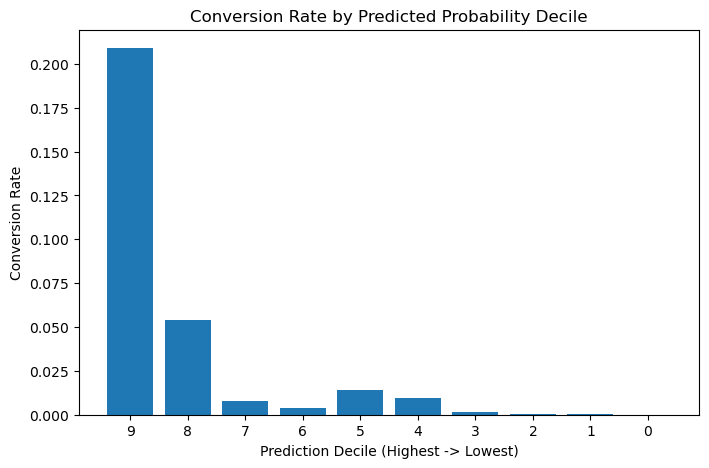

In [12]:
decile_summary_sorted = decile_summary.sort_index(ascending = False)

plt.figure(figsize = (8,5))
plt.bar(decile_summary_sorted.index.astype(str),
        decile_summary_sorted["actual_conversion_rate"])
plt.xlabel("Prediction Decile (Highest -> Lowest)")
plt.ylabel("Conversion Rate")
plt.title("Conversion Rate by Predicted Probability Decile")

plt.show()

## Marketing Profit Simulation

using the predicted probabilities, we simulate a targeted advertising strategy to estimate potential revenue imapct under different lift assumptions.

In [13]:
# ----------------------------------------
# Marketing Profit Simulation
# ----------------------------------------
# Simulates profitability of targeting high-intent sessions
# with a paid advertisement campaign

def marketing_profit_simulation (
    audience_size,
    conversion_rate,
    lift,
    aov,
    ad_cost
):
    baseline_conversion = audience_size * conversion_rate
    baseline_revenue = baseline_conversion * aov

    new_conversion_rate = conversion_rate * (1 + lift)
    new_conversions = audience_size * new_conversion_rate
    new_revenue = new_conversions * aov

    incremental_revenue = new_revenue - baseline_revenue
    total_ad_cost = audience_size * ad_cost

    net_profit = incremental_revenue - total_ad_cost

    return net_profit

In [14]:
profit = marketing_profit_simulation(
    audience_size = 6661,
    conversion_rate = 0.209278,
    lift = 0.05,
    aov = 41.103037614266455,
    ad_cost = 1
)

profit

-3796.116720480495

In [15]:
ad_cost = 1
AOV = 41.103037614266455

decile_summary["required_lift"] = (
    ad_cost / (decile_summary["actual_conversion_rate"] * AOV)
)

decile_summary["required_lift"] = np.where(
    decile_summary["actual_conversion_rate"] > 0,
    ad_cost / (decile_summary["actual_conversion_rate"] * AOV),
    np.inf
)

decile_summary["required_lift_pct"] = (decile_summary["required_lift"] * 100)

decile_summary[["actual_conversion_rate","required_lift_pct"]]

,actual_conversion_rate,required_lift_pct
deciles,,
9,0.208978,11.641965
8,0.054054,45.008839
7,0.007658,317.709451
6,0.003603,675.233955
5,0.014114,172.374277
4,0.009610,253.174719
3,0.001502,1619.831620
2,0.000450,5403.493583
1,0.000601,4050.187277


## Business Recommendations

1. Increase exposure to high-intent users
   - Users exploring multiple brands show strong purchase intent.

2. Reduce friction in the checkout process
   - Converting sessions exhibit significantly longer interaction time.

3. Retarget high-intent non-converting sessions
   - Top decile users convert 7x more frequently than average.

4. Improve acquisition quality
   - Majority of traffic does not reach cart stage.

5. Implement a real-time conversion scoring system
   - Enables prioritization of high-value sessions for marketing.